# Network Graph Analytics
## UPF Digital Twin — Forecasting Module: Data Foundation

This notebook documents the spatial and temporal structure of the Lyon gNodeB dataset.
It supports the thesis chapter on the forecasting module and produces all publication-quality figures.

**Three sections:**
1. Spatial Structure — BS deployment, Voronoi cells, graph topology
2. Traffic Signal Properties — temporal patterns, periodicity, spatial heterogeneity
3. Graph Representation — adjacency, edge weights, input tensor structure

In [61]:
import os, sys, math, warnings, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import geopandas as gpd
from shapely.geometry import shape, box as shapely_box, Point
from shapely.ops import unary_union
import contextily as cx

from statsmodels.tsa.stattools import acf
import yaml

warnings.filterwarnings("ignore")

# -- Project root --
_here = Path().resolve()
ROOT  = _here if (_here / "params.yaml").exists() else _here.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.aggregate import load_base_stations, build_voronoi, build_tile_centroids, VoronoiResult, _latlon_to_xy

with open(ROOT / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)

FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# -- Plot style --
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})

BLUE   = "#1a6faf"
ORANGE = "#e07b39"
GREEN  = "#2ca02c"
GRAY   = "#888888"
SERVICE_COLORS = {"YouTube": BLUE, "Netflix": ORANGE, "DailyMotion": GREEN}

print(f"ROOT: {ROOT}")
print("Setup complete.")

ROOT: C:\Users\Shima\Desktop\UPF_DigitalTwin
Setup complete.


## Load All Artefacts

In [42]:
# ── Graph artefacts ───────────────────────────────────────────────────────────
bs_df       = pd.read_parquet(ROOT / "data/graphs/bs_locations.parquet")
voronoi_map = pd.read_parquet(ROOT / "data/graphs/voronoi_map.parquet")     # tile_id → site_id
node_index  = pd.read_parquet(ROOT / "data/graphs/node_index.parquet")      # site_id → node_idx
graph_edges = pd.read_parquet(ROOT / "data/graphs/graph_edges.parquet")     # src, dst, distance_km
edge_index  = np.load(ROOT / "data/graphs/edge_index.npy")                  # (2, 2E)
edge_attr   = np.load(ROOT / "data/graphs/edge_attr.npy")                   # (2E,)

# ── GeoJSON city boundary ─────────────────────────────────────────────────────
import json
geojson_path = ROOT / PARAMS["aggregation"]["geojson_path"]
with open(geojson_path, encoding="utf-8") as f:
    _gj = json.load(f)
city_boundary = unary_union([shape(feat["geometry"]) for feat in _gj["features"]])
_b = city_boundary.bounds   # (lon_min, lat_min, lon_max, lat_max)
CITY_EXT = dict(lon_min=_b[0]-0.01, lat_min=_b[1]-0.01,
                lon_max=_b[2]+0.01, lat_max=_b[3]+0.01)

# White mask: covers everything outside the city boundary
_pad    = 2.0
_bigbox = shapely_box(_b[0]-_pad, _b[1]-_pad, _b[2]+_pad, _b[3]+_pad)
outside = _bigbox.difference(city_boundary)

# ── Voronoi result — MUST use the same city_boundary the pipeline used ────────
# load_base_stations with city_boundary gives the same BS set as the DVC stage.
# Without it, bbox filtering returns ~1086 BSs instead of 965, causing a
# polygon→site_id index mismatch with voronoi_map.parquet.
bs_all  = load_base_stations(PARAMS, city_boundary=city_boundary)
vresult = build_voronoi(bs_all, PARAMS, city_boundary=city_boundary)
lat_ref = vresult.lat_ref
R       = 6_371_000.0

def xy_to_lonlat(x, y):
    lon = np.degrees(x / (R * math.cos(math.radians(lat_ref))))
    lat = np.degrees(y / R)
    return lon, lat

# ── Processed traffic (lazy — load on demand) ─────────────────────────────────
PROC_FILES = sorted(glob.glob(str(ROOT / "data/netmob/processed/Lyon_*.parquet")))
print(f"BS locations   : {len(bs_df):,} nodes")
print(f"bs_all (pipeline-consistent): {len(bs_all):,} BSs")
print(f"Voronoi map    : {len(voronoi_map):,} tiles -> {voronoi_map['site_id'].nunique():,} BSs")
print(f"Graph edges    : {len(graph_edges):,} undirected  |  {edge_index.shape[1]:,} directed (PyG)")
print(f"Processed files: {len(PROC_FILES)} days")

[aggregate] Removed 15 co-located BS duplicates (983 -> 968 unique positions)
[aggregate] Loaded 968 base stations
[aggregate] Built 968 Voronoi coverage polygons (clipped to city footprint, 0 empty)
BS locations   : 965 nodes
bs_all (pipeline-consistent): 968 BSs
Voronoi map    : 54,013 tiles -> 965 BSs
Graph edges    : 2,772 undirected  |  5,544 directed (PyG)
Processed files: 77 days


## Helper: City Map Utilities

In [43]:
def _shapely_to_mpl_path(geom):
    """Convert a Shapely Polygon or MultiPolygon (with holes) to a Matplotlib Path."""
    from shapely.geometry import MultiPolygon, Polygon
    polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
    verts, codes = [], []
    for poly in polys:
        for ring in [poly.exterior] + list(poly.interiors):
            xy = np.array(ring.coords)
            verts.append(xy)
            codes.append(
                [MplPath.MOVETO] + [MplPath.LINETO] * (len(xy) - 2) + [MplPath.CLOSEPOLY]
            )
    if not verts:
        return None
    return MplPath(np.concatenate(verts), np.concatenate(codes))


def _add_city_mask(ax, alpha=1.0):
    """White overlay that hides everything outside the city boundary."""
    p = _shapely_to_mpl_path(outside)
    if p:
        ax.add_patch(PathPatch(p, facecolor="white", edgecolor="none",
                               alpha=alpha, zorder=5, transform=ax.transData))


def _add_city_outline(ax, color="#333333", lw=0.8):
    """Draw the city border on top of the mask."""
    from shapely.geometry import MultiPolygon
    polys = list(city_boundary.geoms) if city_boundary.geom_type == "MultiPolygon" else [city_boundary]
    for poly in polys:
        x, y = poly.exterior.xy
        ax.plot(x, y, color=color, lw=lw, zorder=6)


def _add_basemap(ax, zoom=12):
    """Add OSM basemap via contextily."""
    try:
        cx.add_basemap(ax, crs="EPSG:4326", zoom=zoom,
                       source=cx.providers.OpenStreetMap.Mapnik, zorder=0)
    except Exception:
        pass   # graceful fallback if offline


def _set_city_extent(ax):
    ax.set_xlim(CITY_EXT["lon_min"], CITY_EXT["lon_max"])
    ax.set_ylim(CITY_EXT["lat_min"], CITY_EXT["lat_max"])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")


print("Map helpers ready.")

Map helpers ready.


# Section 1 — Spatial Structure

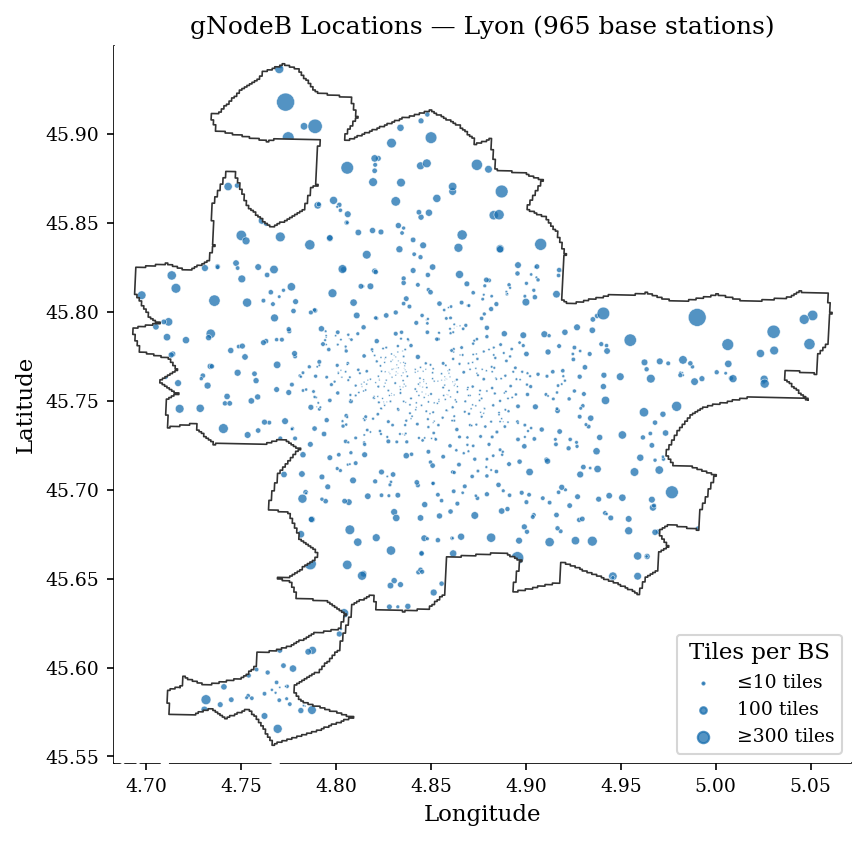

In [44]:
### Fig 1 — BS Location Map
# Distribution of 965 gNodeBs across Lyon.
# Dots sized by number of assigned tiles; color constant.

fig, ax = plt.subplots(figsize=(7, 7))

tiles_per_bs = voronoi_map.groupby("site_id").size().rename("n_tiles")
bs_plot = bs_df.merge(tiles_per_bs.reset_index(), on="site_id", how="left").fillna(1)

_add_basemap(ax, zoom=12)

sc = ax.scatter(
    bs_plot["lon"], bs_plot["lat"],
    s=bs_plot["n_tiles"] / 10,
    c=BLUE, alpha=0.75, linewidths=0.3, edgecolors="white", zorder=4
)

_add_city_mask(ax)
_add_city_outline(ax)
_set_city_extent(ax)

ax.set_title(f"gNodeB Locations — Lyon ({len(bs_df):,} base stations)")

# size legend
for n_tiles, label in [(10, "≤10 tiles"), (100, "100 tiles"), (300, "≥300 tiles")]:
    ax.scatter([], [], s=n_tiles / 10, c=BLUE, alpha=0.75, label=label)
ax.legend(title="Tiles per BS", frameon=True, loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES / "fig1_bs_locations.pdf", bbox_inches="tight")
plt.show()

Plotting 979 Voronoi polygons for 192 unique tile counts


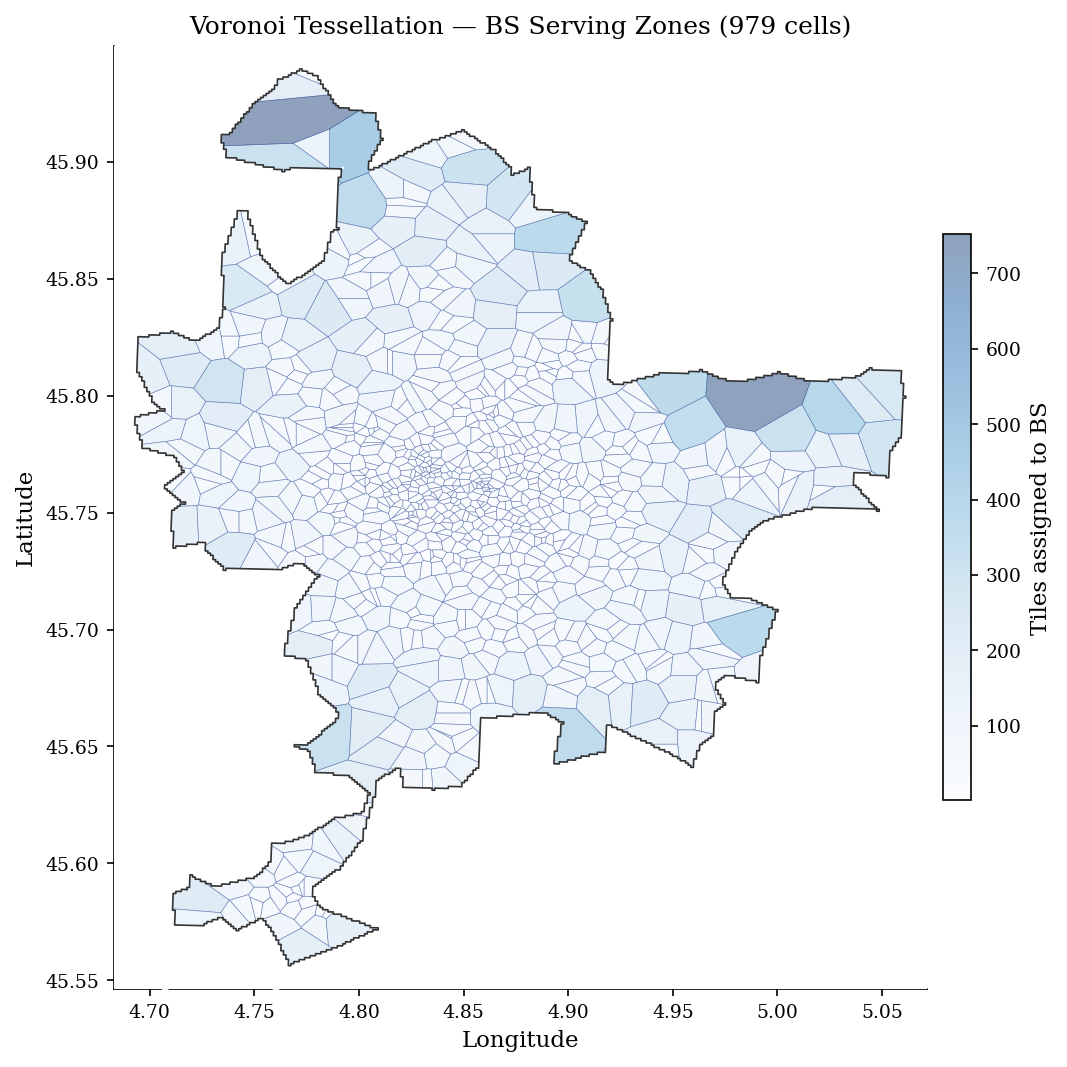

In [69]:
### Fig 2 — Voronoi Tessellation
# Each polygon = one BS's serving zone derived by Voronoi.
# Color encodes number of tiles assigned to that BS.
#
# IMPORTANT: vresult.polygons[i] corresponds to bs_all.iloc[i] — the same
# DataFrame passed to build_voronoi(). We use bs_all here, NOT bs_df/bs_sorted,
# to avoid an index mismatch (bs_df has only the 965 active BSs; bs_all may
# include additional BSs whose polygons got no tiles).

from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

tile_counts = voronoi_map.groupby("site_id").size()  # site_id → n_tiles
poly_patches, poly_ntiles = [], []

for i, poly in enumerate(vresult.polygons):
    if poly is None or poly.is_empty:
        continue

    sid = str(bs_all.iloc[i]["site_id"])
    n   = int(tile_counts.get(sid, 0))   # 0 = BS present but no assigned tiles
    if n == 0:
        continue   # skip BSs outside the city / with no tile data

    geoms = list(poly.geoms) if poly.geom_type == "MultiPolygon" else [poly]
    for part in geoms:
        xy = np.array(part.exterior.coords)   # (K, 2) in XY metres
        lon, lat = xy_to_lonlat(xy[:, 0], xy[:, 1])
        poly_patches.append(MplPolygon(np.column_stack([lon, lat]), closed=True))
        poly_ntiles.append(n)

print(f"Plotting {len(poly_patches)} Voronoi polygons for {len(set(poly_ntiles))} unique tile counts")

fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
_add_basemap(ax, zoom=12)

cmap ='Blues'
pc = PatchCollection(poly_patches, cmap=cmap, alpha=0.45, linewidths=0.3,
                     edgecolors="#1a3a8f", zorder=3)
pc.set_array(np.array(poly_ntiles))
ax.add_collection(pc)

_add_city_mask(ax)
_add_city_outline(ax)
_set_city_extent(ax)

cbar = plt.colorbar(pc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Tiles assigned to BS")
ax.set_title(f"Voronoi Tessellation — BS Serving Zones ({len(poly_patches)} cells)")

plt.savefig(FIGURES / "fig2_voronoi.pdf", bbox_inches="tight")
plt.show()

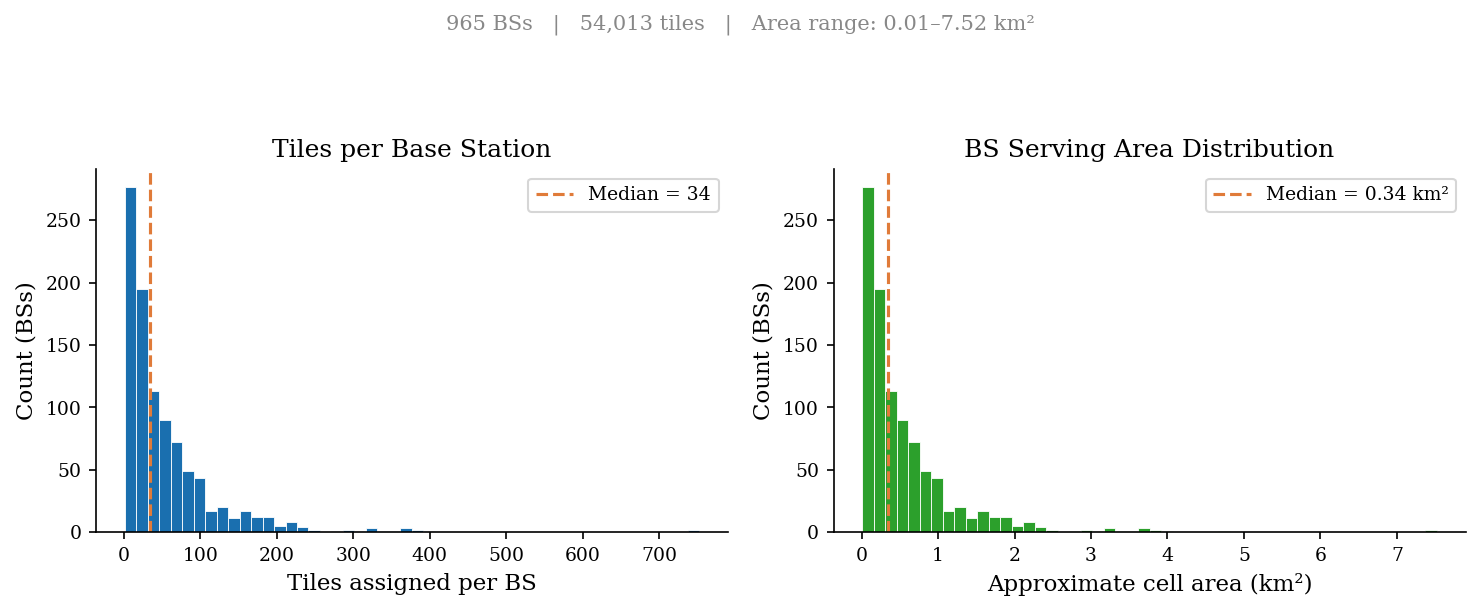

In [46]:
### Fig 3 — Cell Size Distributions  (tiles per BS + approximate area)
# Two panels: (left) histogram of tiles/BS, (right) approximate cell area in km².
# Motivates why a graph is needed — cells are highly irregular.

tiles_per_bs = voronoi_map.groupby("site_id").size()
tile_area_km2 = (100 * 100) / 1e6          # each tile = 0.01 km²
cell_area_km2 = tiles_per_bs * tile_area_km2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: tiles per BS
ax = axes[0]
ax.hist(tiles_per_bs, bins=50, color=BLUE, edgecolor="white", linewidth=0.4)
ax.axvline(tiles_per_bs.median(), color=ORANGE, lw=1.5, linestyle="--",
           label=f"Median = {tiles_per_bs.median():.0f}")
ax.set_xlabel("Tiles assigned per BS")
ax.set_ylabel("Count (BSs)")
ax.set_title("Tiles per Base Station")
ax.legend()

# Right: cell area
ax = axes[1]
ax.hist(cell_area_km2, bins=50, color=GREEN, edgecolor="white", linewidth=0.4)
ax.axvline(cell_area_km2.median(), color=ORANGE, lw=1.5, linestyle="--",
           label=f"Median = {cell_area_km2.median():.2f} km²")
ax.set_xlabel("Approximate cell area (km²)")
ax.set_ylabel("Count (BSs)")
ax.set_title("BS Serving Area Distribution")
ax.legend()

plt.suptitle(
    f"965 BSs   |   54,013 tiles   |   Area range: "
    f"{cell_area_km2.min():.2f}–{cell_area_km2.max():.2f} km²",
    y=1.01, fontsize=10, color=GRAY
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "fig3_cell_size_distributions.pdf", bbox_inches="tight")
plt.show()

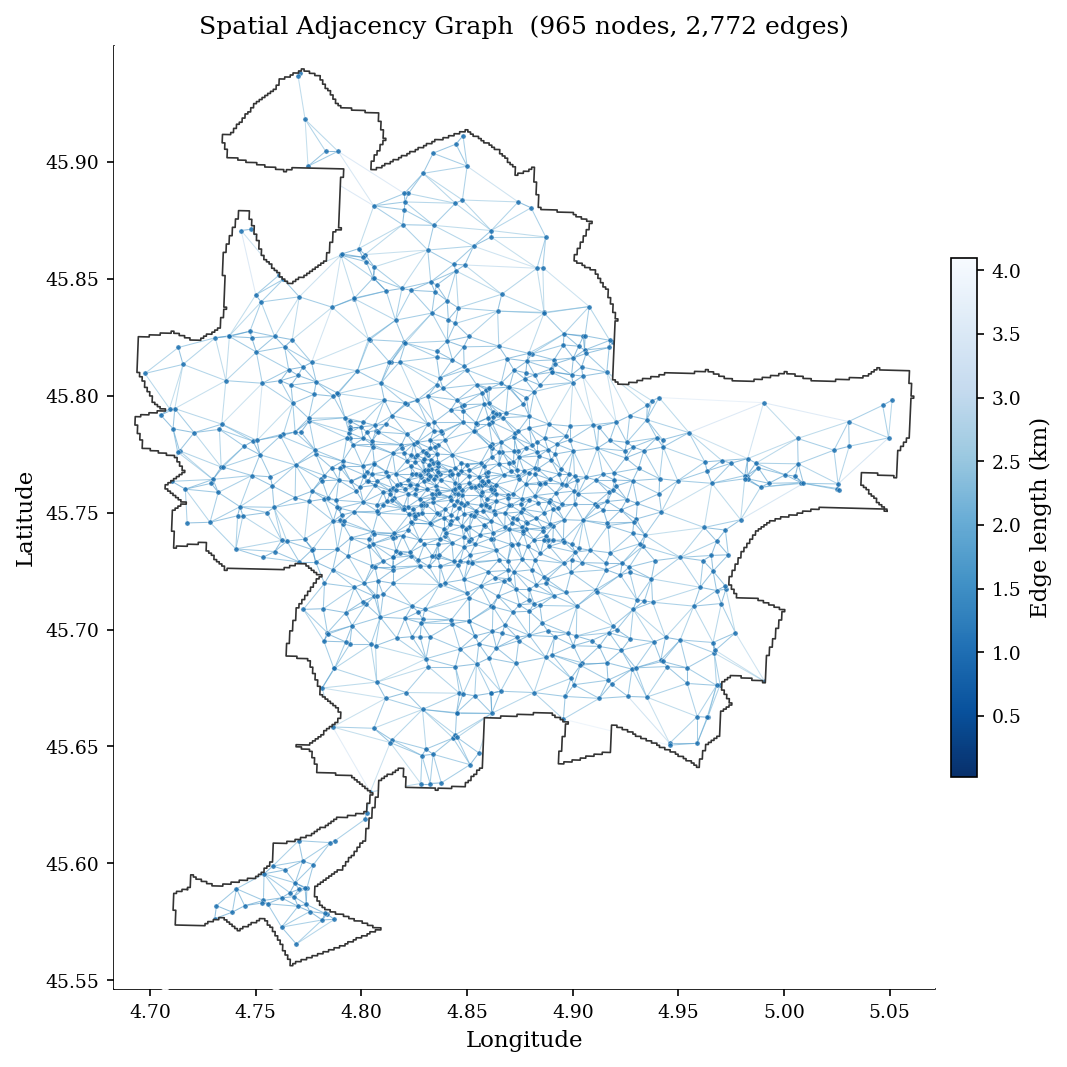

In [47]:
### Fig 4 — Spatial Adjacency Graph
# 965 nodes, 2880 undirected edges on city map.
# Edge color encodes Haversine distance (km); line width constant.

fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
_add_basemap(ax, zoom=12)

# Draw edges first (below nodes)
edge_cmap = plt.cm.Blues_r
dist_vals  = graph_edges["distance_km"].values
norm_dist  = (dist_vals - dist_vals.min()) / (dist_vals.max() - dist_vals.min() + 1e-9)

bs_coord = bs_df.set_index("site_id")[["lon", "lat"]]
for (_, row), nd in zip(graph_edges.iterrows(), norm_dist):
    src = str(row["src_site_id"])
    dst = str(row["dst_site_id"])
    if src in bs_coord.index and dst in bs_coord.index:
        xs = [bs_coord.loc[src, "lon"], bs_coord.loc[dst, "lon"]]
        ys = [bs_coord.loc[src, "lat"], bs_coord.loc[dst, "lat"]]
        ax.plot(xs, ys, color=edge_cmap(0.3 + 0.6 * nd), lw=0.5, alpha=0.6, zorder=2)

# Nodes
ax.scatter(bs_df["lon"], bs_df["lat"], s=6, c=BLUE,
           edgecolors="white", linewidths=0.2, zorder=4, alpha=0.85)

_add_city_mask(ax)
_add_city_outline(ax)
_set_city_extent(ax)

# Colorbar for edge distance
sm = plt.cm.ScalarMappable(cmap=edge_cmap,
                            norm=mcolors.Normalize(dist_vals.min(), dist_vals.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("Edge length (km)")

ax.set_title(f"Spatial Adjacency Graph  ({len(bs_df):,} nodes, {len(graph_edges):,} edges)")

plt.savefig(FIGURES / "fig4_spatial_graph.pdf", bbox_inches="tight")
plt.show()

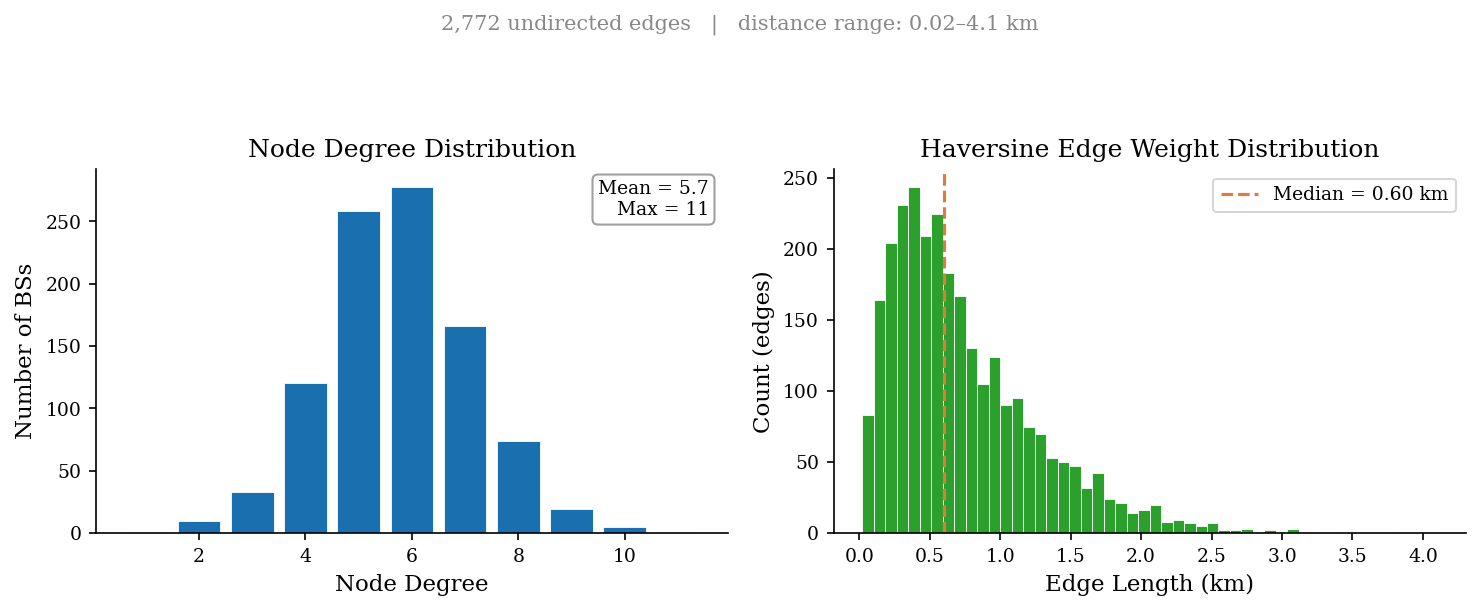

In [48]:
### Fig 5 — Graph Topology Statistics  (degree + edge weight)
# Two panels: (left) node degree distribution, (right) edge weight histogram.
# Degree informs message-passing depth; distance distribution justifies weighting.

all_nodes = pd.concat([graph_edges["src_site_id"], graph_edges["dst_site_id"]])
degree = all_nodes.value_counts().rename("degree")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left — degree distribution
ax = axes[0]
deg_counts = degree.value_counts().sort_index()
ax.bar(deg_counts.index, deg_counts.values, color=BLUE, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Node Degree")
ax.set_ylabel("Number of BSs")
ax.set_title("Node Degree Distribution")
ax.text(0.97, 0.97, f"Mean = {degree.mean():.1f}\nMax = {degree.max()}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8))

# Right — edge weight distribution
ax = axes[1]
# Use undirected edges only (graph_edges already undirected)
ax.hist(graph_edges["distance_km"], bins=50, color=GREEN,
        edgecolor="white", linewidth=0.4)
ax.axvline(graph_edges["distance_km"].median(), color=ORANGE, lw=1.5,
           linestyle="--", label=f"Median = {graph_edges['distance_km'].median():.2f} km")
ax.set_xlabel("Edge Length (km)")
ax.set_ylabel("Count (edges)")
ax.set_title("Haversine Edge Weight Distribution")
ax.legend()

plt.suptitle(
    f"{len(graph_edges):,} undirected edges   |   "
    f"distance range: {graph_edges['distance_km'].min():.2f}–{graph_edges['distance_km'].max():.1f} km",
    y=1.01, fontsize=10, color=GRAY
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "fig5_graph_topology.pdf", bbox_inches="tight")
plt.show()

# Section 2 — Traffic Signal Properties

In [49]:
### Load and aggregate traffic — run once, reuse below

dfs = []
for f in PROC_FILES:
    d = pd.read_parquet(f)
    dfs.append(d)
traffic = pd.concat(dfs, ignore_index=True)
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])
traffic["date"]      = traffic["timestamp"].dt.date
traffic["hour"]      = traffic["timestamp"].dt.hour
traffic["slot"]      = (traffic["timestamp"].dt.hour * 4 +
                        traffic["timestamp"].dt.minute // 15)   # 0–95
traffic["dow"]       = traffic["timestamp"].dt.dayofweek        # 0=Mon
traffic["is_weekend"]= traffic["dow"] >= 5

# City-level aggregate per slot per service
city_ts = (traffic
           .groupby(["timestamp", "service"])["dl_norm"]
           .sum()
           .reset_index()
           .sort_values("timestamp"))

print(f"Traffic records: {len(traffic):,}")
print(f"Date range     : {traffic['timestamp'].min()} -> {traffic['timestamp'].max()}")
print(f"BSs in traffic : {traffic['site_id'].nunique():,}")

Traffic records: 21,565,572
Date range     : 2019-03-16 00:00:00 -> 2019-05-31 23:45:00
BSs in traffic : 973


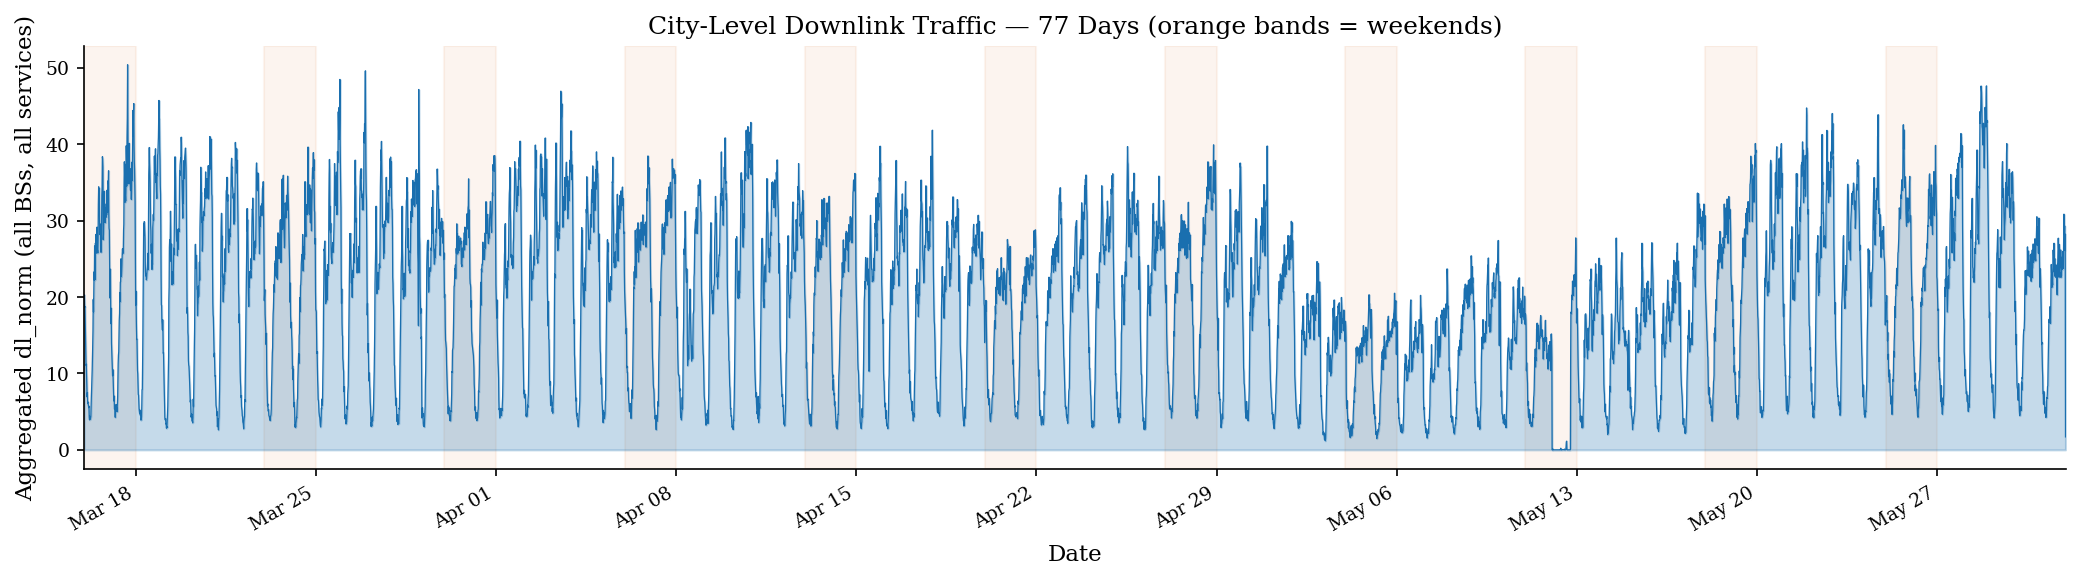

In [50]:
### Fig 6 — City-Level Aggregate Traffic (77 days)
# Total downlink load summed across all BSs per 15-min slot.
# Reveals macro periodicities and overall dataset shape.

city_total = (city_ts
              .groupby("timestamp")["dl_norm"]
              .sum()
              .reset_index()
              .rename(columns={"dl_norm": "total"}))
city_total["timestamp"] = pd.to_datetime(city_total["timestamp"])

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(city_total["timestamp"], city_total["total"],
                alpha=0.25, color=BLUE)
ax.plot(city_total["timestamp"], city_total["total"],
        color=BLUE, lw=0.6)

# Mark weekends with light shading
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

dates = city_total["timestamp"].dt.date.unique()
for d in dates:
    dow = pd.Timestamp(d).dayofweek
    if dow == 5:   # Saturday — shade Sat+Sun
        t0 = pd.Timestamp(d)
        t1 = t0 + pd.Timedelta(days=2)
        ax.axvspan(t0, t1, color=ORANGE, alpha=0.08, zorder=0)

ax.xaxis.set_major_formatter(DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30, ha="right")
ax.set_xlabel("Date")
ax.set_ylabel("Aggregated dl_norm (all BSs, all services)")
ax.set_title("City-Level Downlink Traffic — 77 Days (orange bands = weekends)")
ax.set_xlim(city_total["timestamp"].min(), city_total["timestamp"].max())

plt.tight_layout()
plt.savefig(FIGURES / "fig6_city_traffic_77days.pdf", bbox_inches="tight")
plt.show()

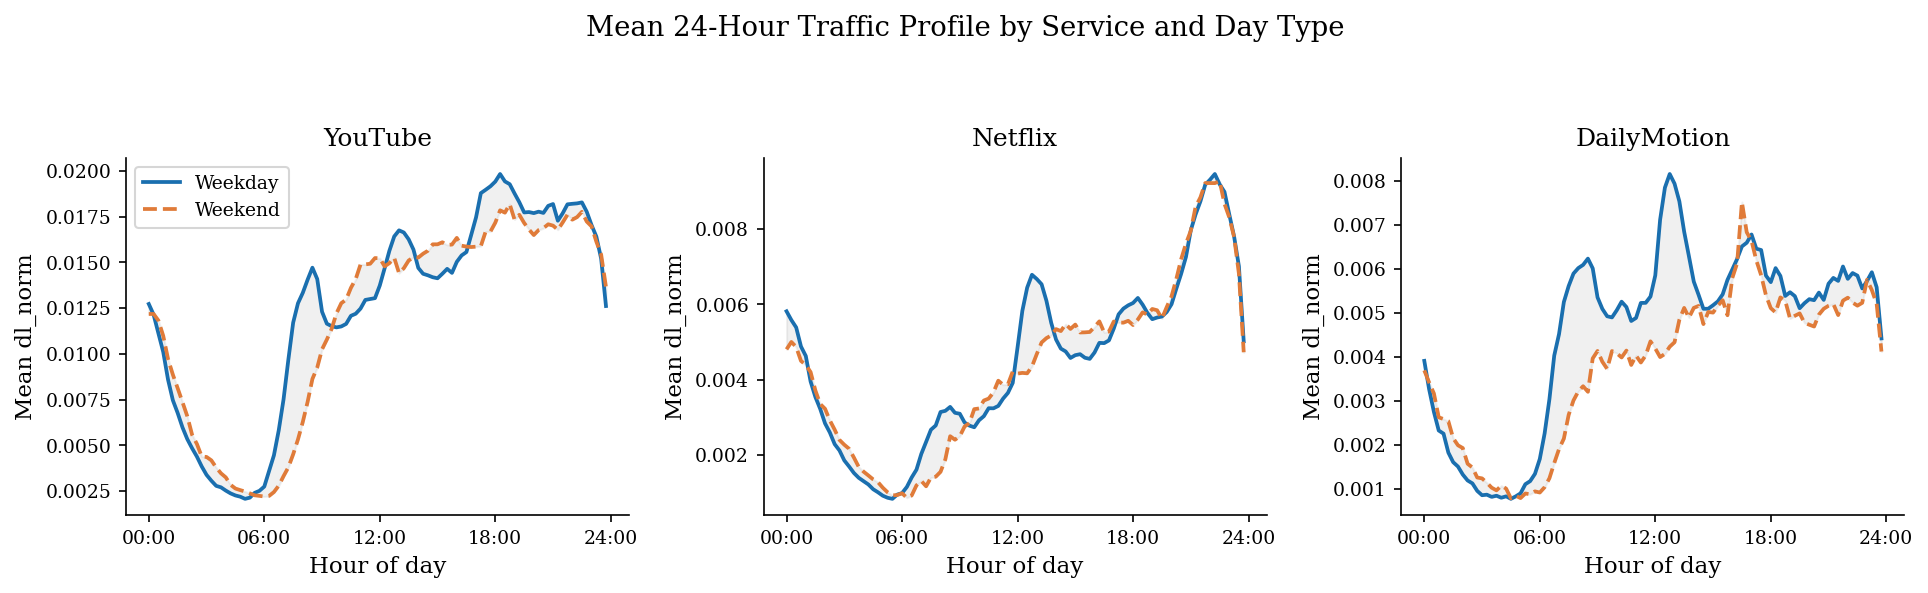

In [51]:
### Fig 7 — Mean Daily Traffic Profile: Weekday vs. Weekend per Service
# Average 24-hour profile split by day type for each OTT service.
# Core thesis figure — demonstrates the periodicity the LSTM must learn.

profile = (traffic
           .groupby(["service", "is_weekend", "slot"])["dl_norm"]
           .mean()
           .reset_index())

slot_hours = np.arange(96) / 4   # 0 … 23.75

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, service in zip(axes, ["YouTube", "Netflix", "DailyMotion"]):
    sub = profile[profile["service"] == service]
    wd  = sub[~sub["is_weekend"]].sort_values("slot")
    we  = sub[sub["is_weekend"]].sort_values("slot")

    ax.plot(slot_hours, wd["dl_norm"].values, color=BLUE,   lw=1.8, label="Weekday")
    ax.plot(slot_hours, we["dl_norm"].values, color=ORANGE, lw=1.8, linestyle="--", label="Weekend")
    ax.fill_between(slot_hours, wd["dl_norm"].values, we["dl_norm"].values,
                    alpha=0.12, color=GRAY)

    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean dl_norm")
    ax.set_title(service)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])
    if ax == axes[0]:
        ax.legend()

plt.suptitle("Mean 24-Hour Traffic Profile by Service and Day Type", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "fig7_daily_profiles.pdf", bbox_inches="tight")
plt.show()

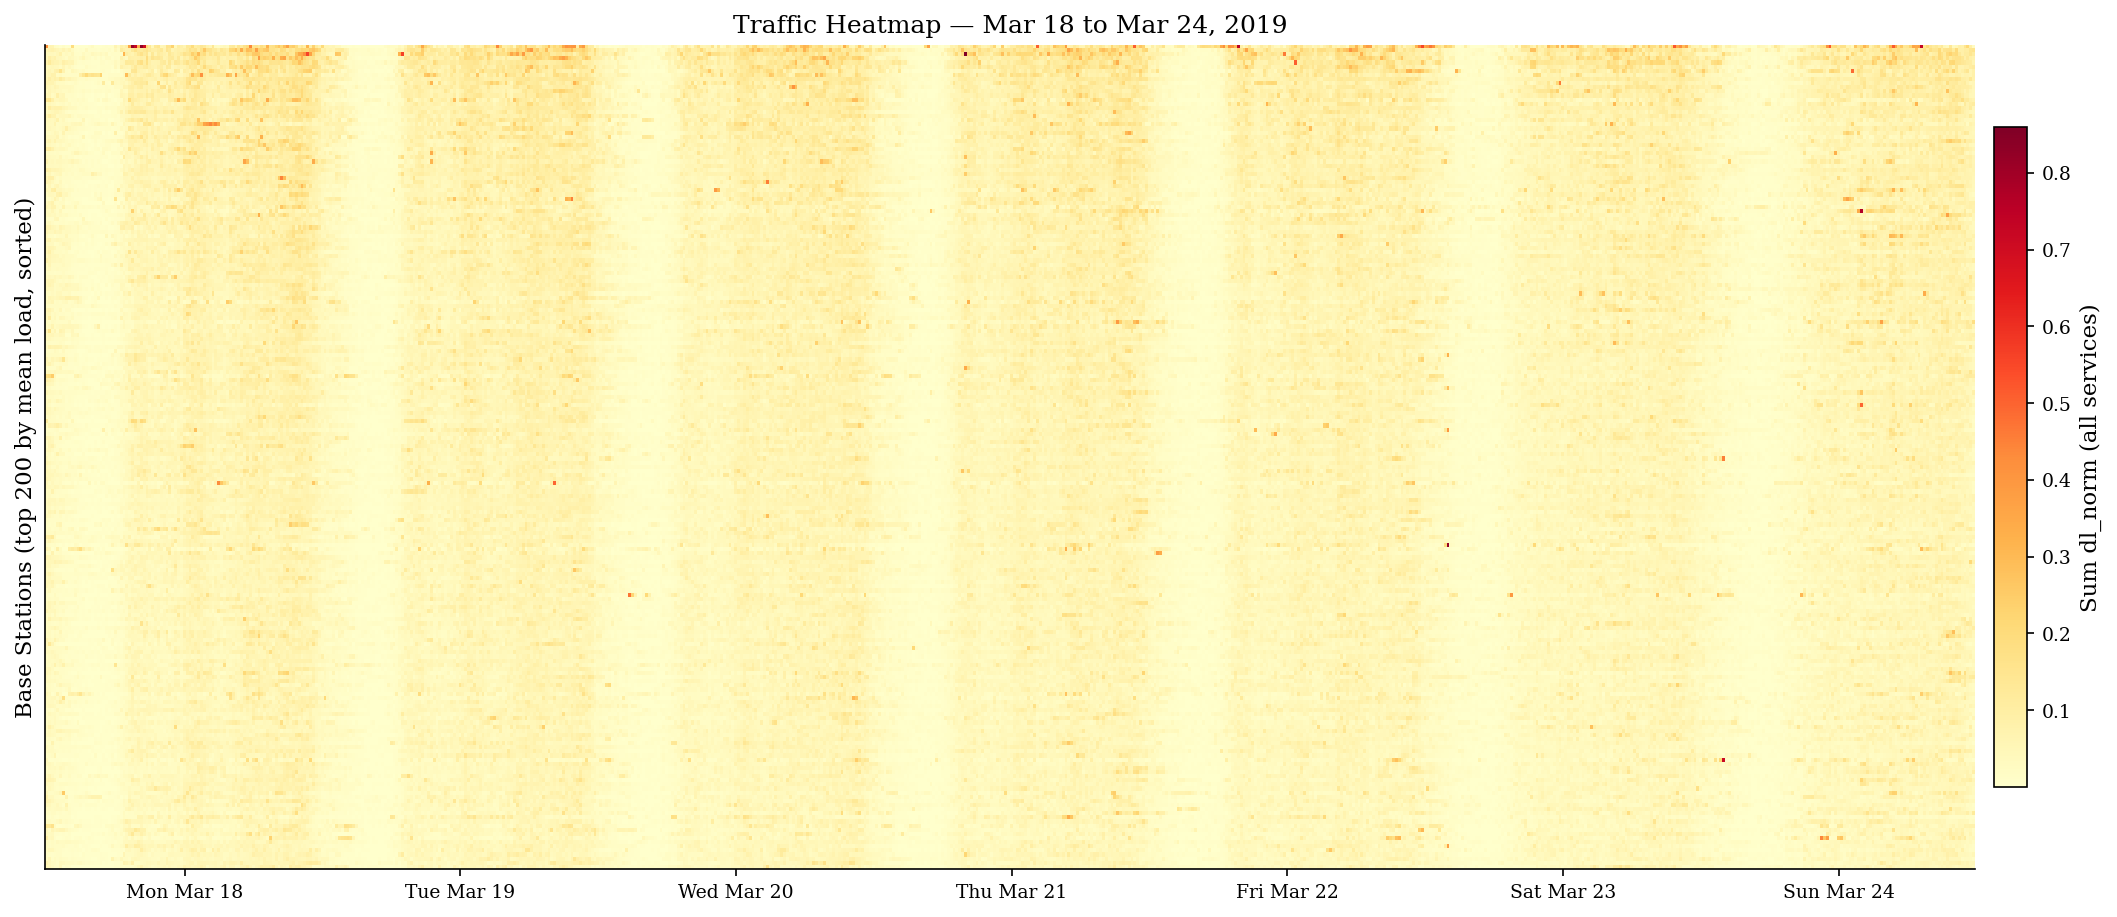

In [52]:
### Fig 8 — Traffic Heatmap: BS × Time (one representative week)
# Rows = BSs sorted by mean load; columns = 15-min slots over 7 days.
# Reveals spatial heterogeneity and temporal regularity simultaneously.

# Pick first full Mon–Sun week
first_mon = None
for d in sorted(traffic["timestamp"].dt.date.unique()):
    if pd.Timestamp(d).dayofweek == 0:
        first_mon = pd.Timestamp(d)
        break

week_end = first_mon + pd.Timedelta(days=7)
week_data = traffic[
    (traffic["timestamp"] >= first_mon) &
    (traffic["timestamp"] < week_end)
]

# Sum services, pivot to BS × slot
week_sum = (week_data
            .groupby(["site_id", "timestamp"])["dl_norm"]
            .sum()
            .reset_index())

pivot = week_sum.pivot(index="site_id", columns="timestamp", values="dl_norm").fillna(0)

# Sort rows by mean load (busiest at top)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

# Subsample to top-200 BSs for a clean heatmap
pivot_plot = pivot.iloc[:200]

# Publishable contrast: clip rare spikes and use a logarithmic colour scale so
# daily bands and medium-load BSs remain visible instead of washing out.
heat_values = pivot_plot.values
positive = heat_values[heat_values > 0]
vmin = max(np.nanpercentile(positive, 1), 1e-4) if positive.size else 1e-4
vmax = np.nanpercentile(positive, 99.5) if positive.size else 1.0

fig, ax = plt.subplots(figsize=(14, 6), layout="constrained")
im = ax.imshow(heat_values, aspect="auto", cmap="YlOrRd",
               norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
               interpolation="nearest")
ax.set_yticks([])
ax.set_ylabel("Base Stations (top 200 by mean load, sorted)")

# X-axis: day labels
n_slots = pivot_plot.shape[1]
day_labels = [first_mon + pd.Timedelta(days=d) for d in range(7)]
ax.set_xticks([d * 96 + 48 for d in range(7)])
ax.set_xticklabels([d.strftime("%a %b %d") for d in day_labels])

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label("Sum dl_norm (all services, log scale; clipped at 99.5th pct.)")

ax.set_title(f"Traffic Heatmap — {first_mon.strftime('%b %d')} to "
             f"{(week_end - pd.Timedelta(days=1)).strftime('%b %d, %Y')}")

plt.savefig(FIGURES / "fig8_traffic_heatmap.pdf", bbox_inches="tight")
plt.show()

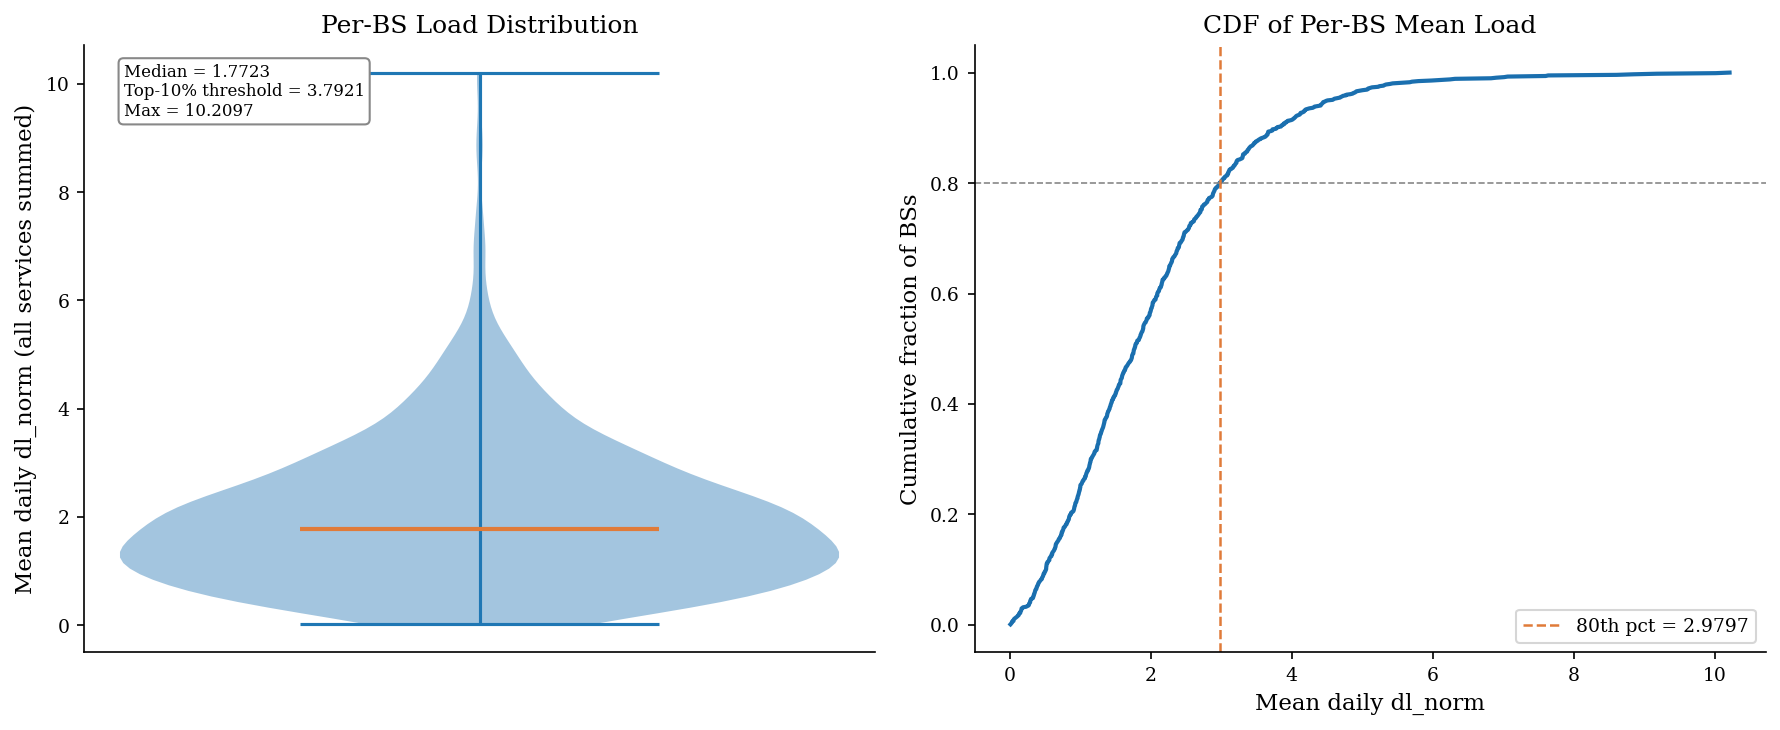

In [53]:
### Fig 9 — Per-BS Load Distribution (violin plot)
# Distribution of mean daily traffic across all 965 BSs.
# Shows the long-tail: a small fraction of BSs carry most load.

bs_mean_load = (traffic
                .groupby(["site_id", "date"])["dl_norm"]
                .sum()             # total load per BS per day (all services)
                .groupby("site_id")
                .mean()            # mean daily load
                .sort_values(ascending=False))

# Decile labels for annotation
deciles = bs_mean_load.quantile(np.arange(0.1, 1.1, 0.1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: violin + strip of mean daily load
ax = axes[0]
from matplotlib.patches import FancyArrowPatch
parts = ax.violinplot(bs_mean_load.values, positions=[0], showmedians=True,
                      showextrema=True)
parts["bodies"][0].set_facecolor(BLUE)
parts["bodies"][0].set_alpha(0.4)
parts["cmedians"].set_color(ORANGE)
parts["cmedians"].set_linewidth(2)
ax.set_xticks([])
ax.set_ylabel("Mean daily dl_norm (all services summed)")
ax.set_title("Per-BS Load Distribution")
ax.text(0.05, 0.97, f"Median = {bs_mean_load.median():.4f}\n"
                     f"Top-10% threshold = {deciles.iloc[-2]:.4f}\n"
                     f"Max = {bs_mean_load.max():.4f}",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY))

# Right: CDF
ax = axes[1]
sorted_load = np.sort(bs_mean_load.values)
cdf = np.arange(1, len(sorted_load) + 1) / len(sorted_load)
ax.plot(sorted_load, cdf, color=BLUE, lw=2)
ax.axhline(0.8, color=GRAY, lw=0.8, linestyle="--")
# Mark x at 80th percentile
p80 = np.percentile(sorted_load, 80)
ax.axvline(p80, color=ORANGE, lw=1.2, linestyle="--",
           label=f"80th pct = {p80:.4f}")
ax.set_xlabel("Mean daily dl_norm")
ax.set_ylabel("Cumulative fraction of BSs")
ax.set_title("CDF of Per-BS Mean Load")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "fig9_bs_load_distribution.pdf", bbox_inches="tight")
plt.show()

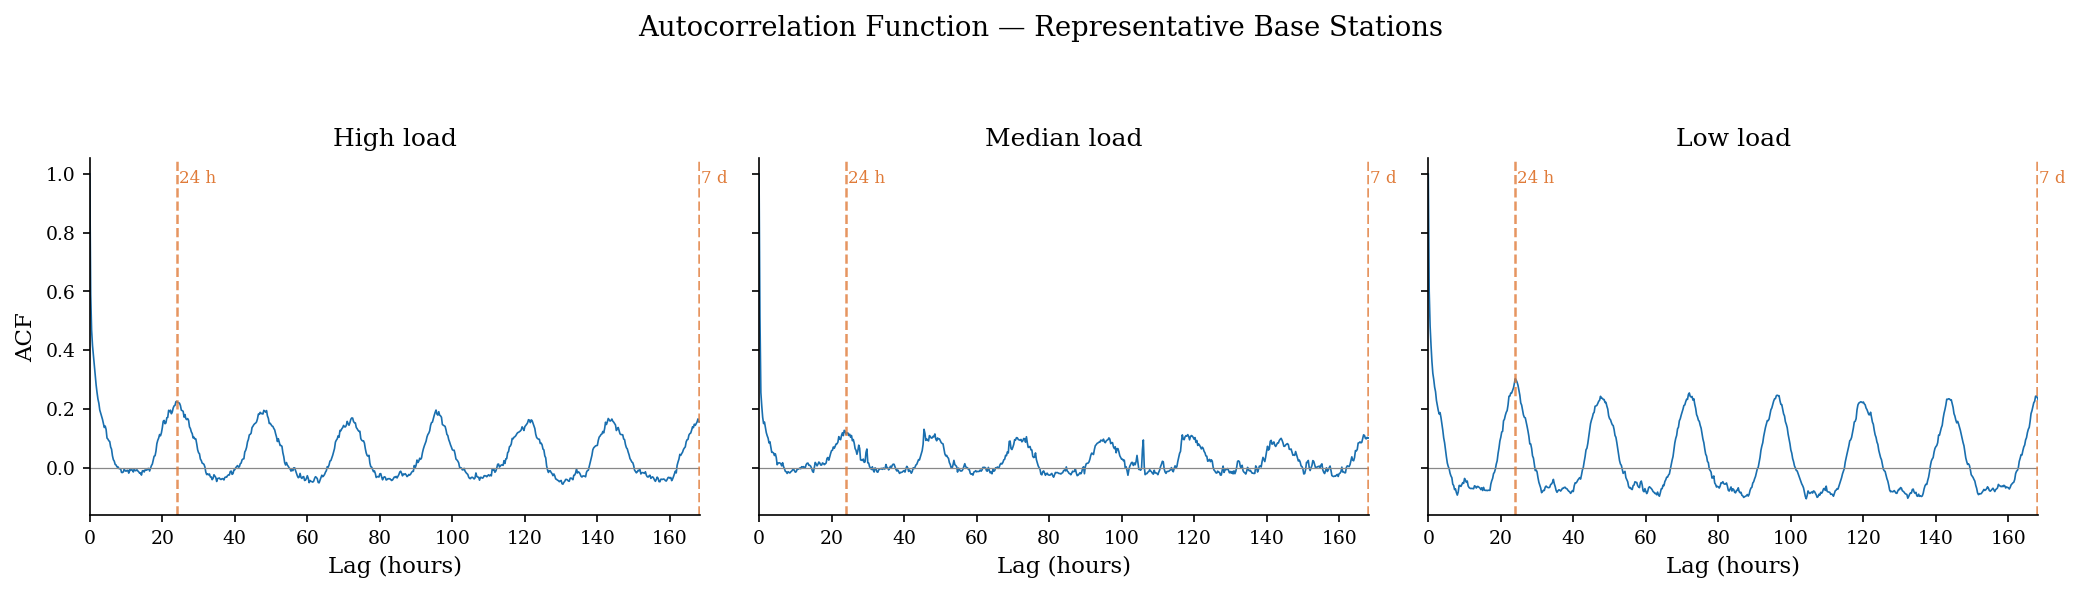

In [54]:
### Fig 10 — Autocorrelation of BS Traffic Signal
# ACF for 3 representative BSs: high / medium / low mean load.
# Confirms 24h and 7-day periodicities that set the LSTM sequence length.

# Pick 3 BSs
top_bs    = bs_mean_load.index[0]
median_bs = bs_mean_load.index[len(bs_mean_load) // 2]
low_bs    = bs_mean_load.index[-50]   # avoid very sparse BSs at absolute bottom

BS_REPR = {
    "High load":   str(top_bs),
    "Median load": str(median_bs),
    "Low load":    str(low_bs),
}

# Build per-BS time series (total = sum of services)
bs_ts_all = (traffic
             .groupby(["site_id", "timestamp"])["dl_norm"]
             .sum()
             .reset_index()
             .sort_values("timestamp"))

MAX_LAG = 96 * 7 + 1   # 7 days in slots

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (label, sid) in zip(axes, BS_REPR.items()):
    ts = (bs_ts_all[bs_ts_all["site_id"] == sid]
          .set_index("timestamp")["dl_norm"]
          .sort_index())
    acf_vals = acf(ts.values, nlags=MAX_LAG, fft=True)
    lags_h = np.arange(MAX_LAG + 1) / 4   # convert slots to hours

    ax.plot(lags_h, acf_vals, color=BLUE, lw=0.8)
    ax.axhline(0, color=GRAY, lw=0.6)

    # Mark key periodicities
    for period_slots, period_label in [(96, "24 h"), (96 * 7, "7 d")]:
        if period_slots <= MAX_LAG:
            ax.axvline(period_slots / 4, color=ORANGE, lw=1.2,
                       linestyle="--", alpha=0.8)
            ax.text(period_slots / 4 + 0.5, 0.92 * ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.5,
                    period_label, fontsize=8, color=ORANGE)

    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("ACF" if ax == axes[0] else "")
    ax.set_title(f"{label}")
    ax.set_xlim(0, MAX_LAG / 4)

plt.suptitle("Autocorrelation Function — Representative Base Stations", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIGURES / "fig10_autocorrelation.pdf", bbox_inches="tight")
plt.show()

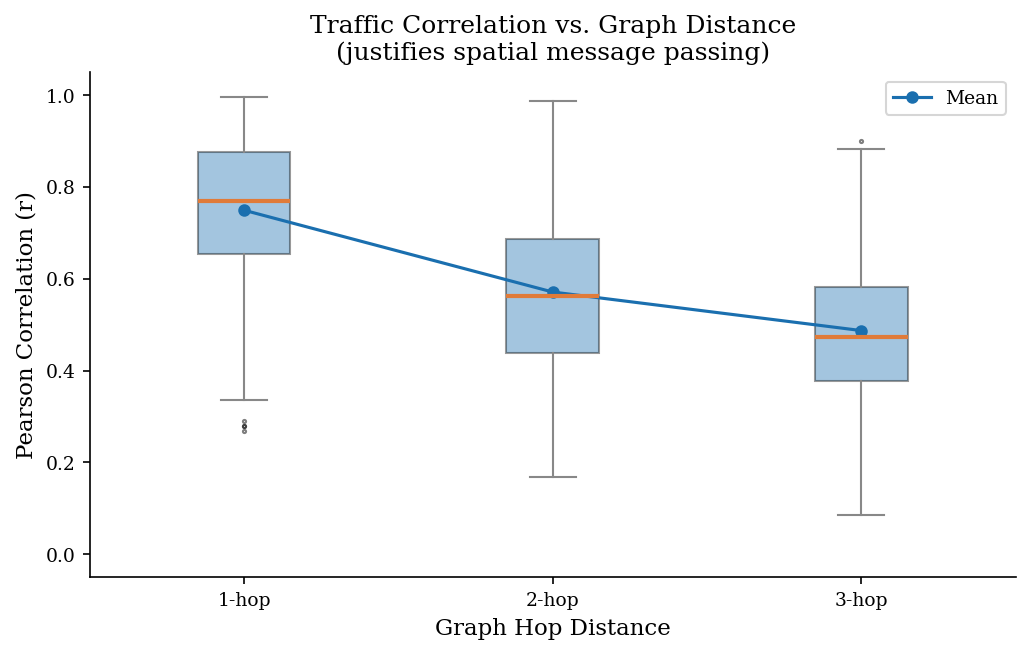

1-hop: n=300, mean r=0.749, median r=0.769
2-hop: n=300, mean r=0.571, median r=0.563
3-hop: n=300, mean r=0.487, median r=0.474


In [55]:
### Fig 11 — Spatial Correlation vs Graph Hop Distance
# Average Pearson correlation between BS pairs at 1/2/3-hop graph distance.
# CORE methodological figure — directly justifies using a GNN.

import networkx as nx
from scipy.stats import pearsonr

# Build NetworkX graph
G = nx.Graph()
G.add_nodes_from(node_index["site_id"].astype(str).tolist())
for _, row in graph_edges.iterrows():
    G.add_edge(str(row["src_site_id"]), str(row["dst_site_id"]))

# Build full BS×time matrix (sum services, use first 2 weeks for speed)
two_weeks = PROC_FILES[:14]
dfs_2w = [pd.read_parquet(f) for f in two_weeks]
t2w = pd.concat(dfs_2w, ignore_index=True)
bs_mat = (t2w.groupby(["site_id", "timestamp"])["dl_norm"]
           .sum()
           .unstack("timestamp")
           .fillna(0))
bs_mat.index = bs_mat.index.astype(str)

# Sample pairs by hop distance (cap at 300 pairs per distance to keep runtime < 30 s)
np.random.seed(42)
HOP_MAX  = 3
N_SAMPLE = 300
results  = {h: [] for h in range(1, HOP_MAX + 1)}

nodes_in_mat = [n for n in G.nodes() if n in bs_mat.index]
sample_nodes = np.random.choice(nodes_in_mat,
                                size=min(200, len(nodes_in_mat)),
                                replace=False)

for src in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G, src, cutoff=HOP_MAX)
    for dst, hops in lengths.items():
        if dst == src or dst not in bs_mat.index:
            continue
        if hops in results and len(results[hops]) < N_SAMPLE:
            r, _ = pearsonr(bs_mat.loc[src].values, bs_mat.loc[dst].values)
            if not np.isnan(r):
                results[hops].append(r)

fig, ax = plt.subplots(figsize=(7, 4.5))

positions = list(range(1, HOP_MAX + 1))
data      = [results[h] for h in positions]
bp = ax.boxplot(data, positions=positions, patch_artist=True,
                medianprops=dict(color=ORANGE, linewidth=2),
                whiskerprops=dict(color=GRAY),
                capprops=dict(color=GRAY),
                flierprops=dict(marker=".", markersize=3, color=GRAY, alpha=0.5))

for patch in bp["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.4)

means = [np.mean(d) for d in data]
ax.plot(positions, means, "o-", color=BLUE, lw=1.5, markersize=5, label="Mean")

ax.set_xlabel("Graph Hop Distance")
ax.set_ylabel("Pearson Correlation (r)")
ax.set_xticks(positions)
ax.set_xticklabels([f"{h}-hop" for h in positions])
ax.set_title("Traffic Correlation vs. Graph Distance\n(justifies spatial message passing)")
ax.legend()
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(FIGURES / "fig11_spatial_correlation.pdf", bbox_inches="tight")
plt.show()

for h in positions:
    print(f"{h}-hop: n={len(results[h])}, mean r={np.mean(results[h]):.3f}, median r={np.median(results[h]):.3f}")

# Section 3 — Graph Representation for the Model

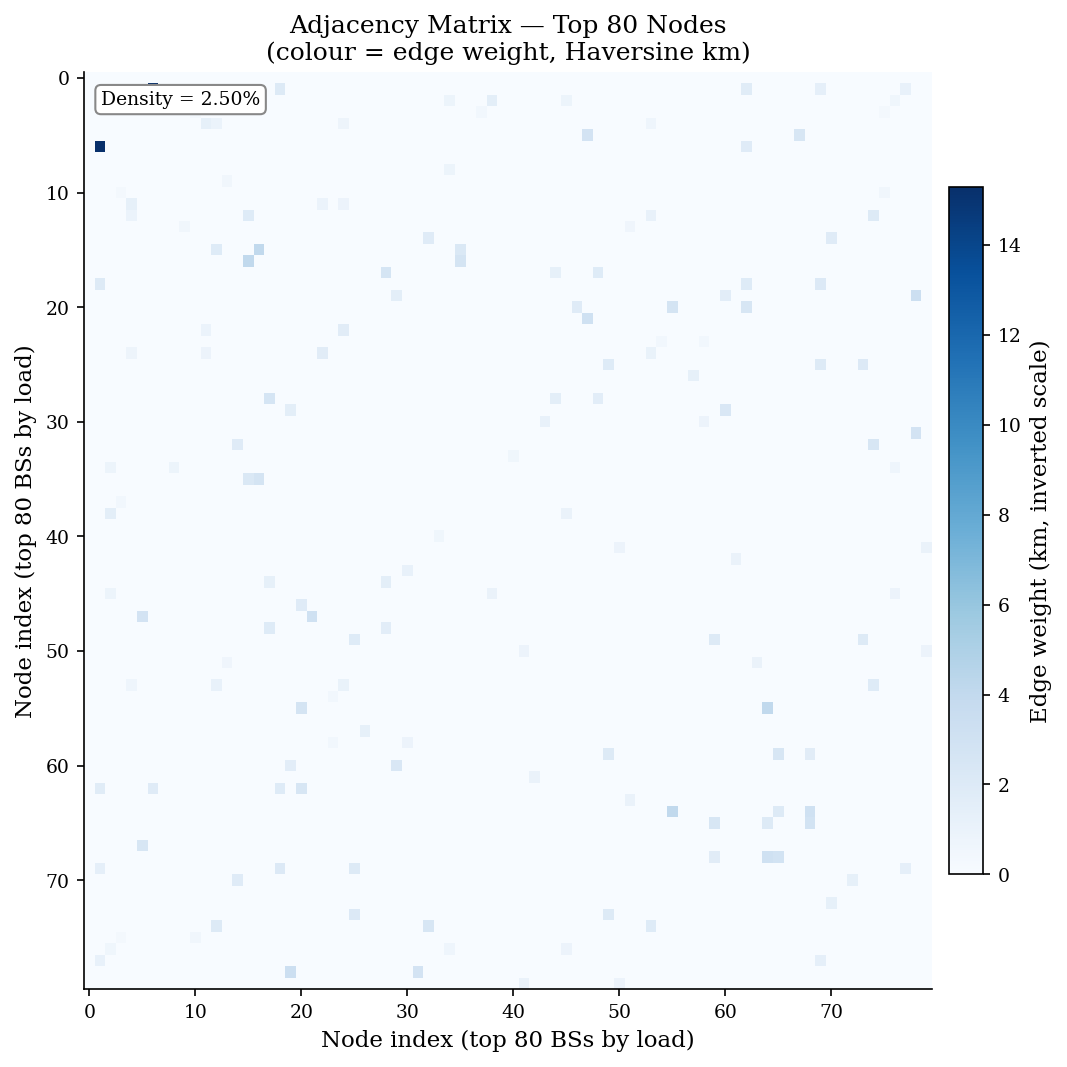

In [56]:
### Fig 12 — Adjacency Matrix (top-80 BSs by mean load)
# Sparse adjacency visualised for the 80 highest-load nodes.
# Shows graph sparsity and local neighbourhood structure passed to PyG.

TOP_N = 80
top_sites = bs_mean_load.head(TOP_N).index.tolist()
top_sites_str = [str(s) for s in top_sites]

# Map to node indices
ni_map = node_index.set_index("site_id")["node_idx"]
top_idx = [int(ni_map.get(s, -1)) for s in top_sites_str]
top_idx_valid = [(i, idx) for i, idx in enumerate(top_idx) if idx >= 0]

# Build dense submatrix from edge_index
size = len(top_idx_valid)
adj = np.zeros((size, size), dtype=np.float32)
idx_set = {idx: i for i, idx in top_idx_valid}

for k in range(edge_index.shape[1]):
    src_i = int(edge_index[0, k])
    dst_i = int(edge_index[1, k])
    if src_i in idx_set and dst_i in idx_set:
        adj[idx_set[src_i], idx_set[dst_i]] = edge_attr[k]

fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
im = ax.imshow(adj, cmap="Blues", aspect="auto", interpolation="nearest")

ax.set_xlabel(f"Node index (top {TOP_N} BSs by load)")
ax.set_ylabel(f"Node index (top {TOP_N} BSs by load)")
ax.set_title(f"Adjacency Matrix — Top {TOP_N} Nodes\n(colour = edge weight, Haversine km)")

cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Edge weight (km, inverted scale)")

density = adj.astype(bool).sum() / (size * size)
ax.text(0.02, 0.98, f"Density = {density:.2%}", transform=ax.transAxes,
        va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY))

plt.savefig(FIGURES / "fig12_adjacency_matrix.pdf", bbox_inches="tight")
plt.show()

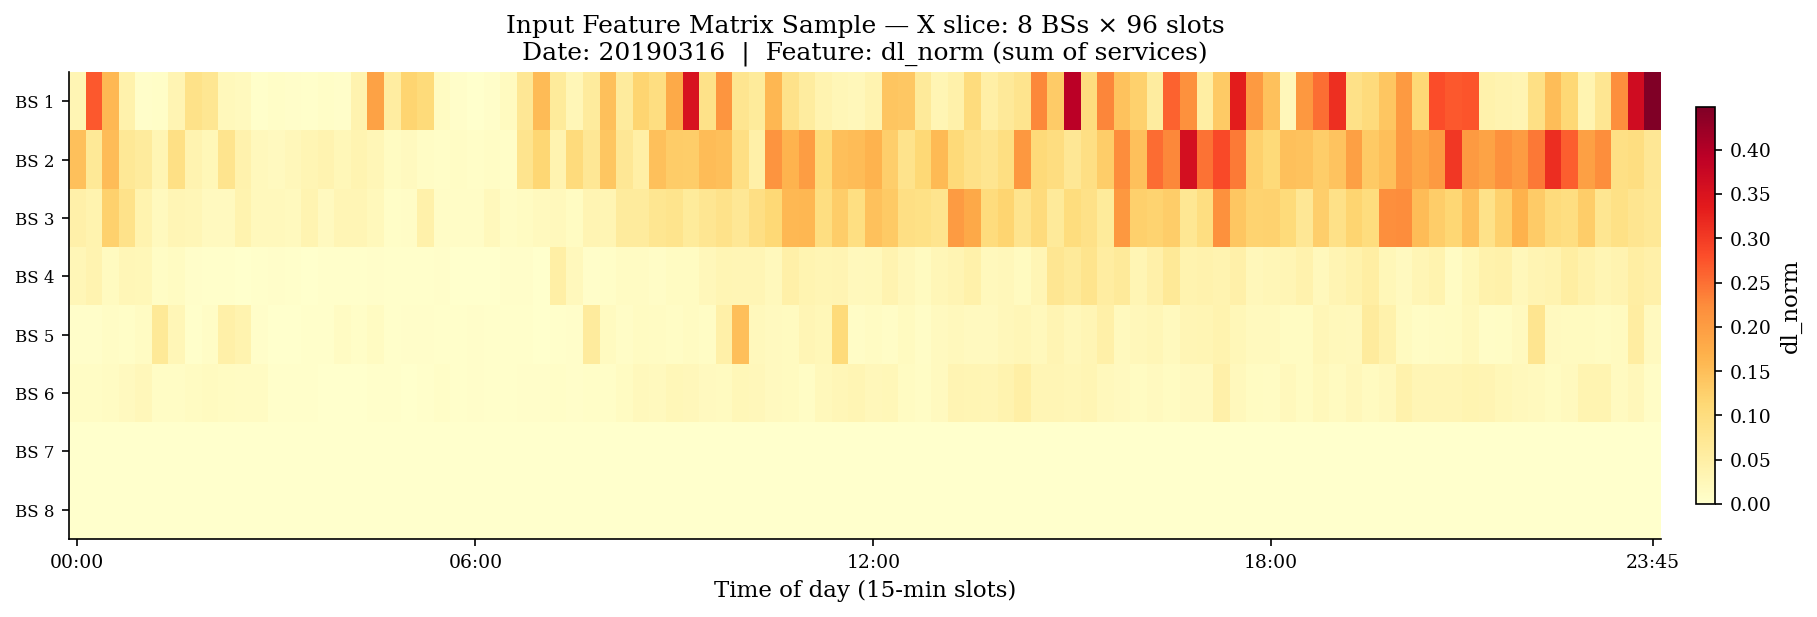

In [57]:
### Fig 13 — Node Feature Matrix Sample  (X slice: 8 BSs × 96 time steps)
# A visual slice of the input tensor X ∈ R^{N×T×F} (F=1 here, single service).
# Makes the model's input format concrete for the thesis reader.

# Pick 8 representative BSs (mix of load levels)
n_show = 8
show_sites = (list(bs_mean_load.head(3).index.astype(str)) +
              list(bs_mean_load.iloc[len(bs_mean_load)//2 - 1 :
                                      len(bs_mean_load)//2 + 2].index.astype(str)) +
              list(bs_mean_load.tail(3).index.astype(str)))[:n_show]

# Take first weekday in dataset
sample_day = PROC_FILES[0]
day_df = pd.read_parquet(sample_day)
day_df["timestamp"] = pd.to_datetime(day_df["timestamp"])
day_sum = (day_df.groupby(["site_id", "timestamp"])["dl_norm"]
           .sum()
           .unstack("timestamp")
           .fillna(0))
day_sum.index = day_sum.index.astype(str)

# Extract slice
slots_96 = day_sum.columns[:96]
mat = day_sum.loc[[s for s in show_sites if s in day_sum.index], slots_96].values

hour_labels = [f"{h:02d}:00" for h in range(0, 25, 6)]

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", interpolation="nearest",
               vmin=0, vmax=mat.max())

ax.set_yticks(range(len(show_sites)))
ax.set_yticklabels([f"BS {i+1}" for i in range(len(show_sites))], fontsize=8)
ax.set_xticks([0, 24, 48, 72, 95])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "23:45"])
ax.set_xlabel("Time of day (15-min slots)")
ax.set_title(
    f"Input Feature Matrix Sample — X slice: {len(show_sites)} BSs × 96 slots\n"
    f"Date: {Path(sample_day).stem.replace('Lyon_', '')}  |  Feature: dl_norm (sum of services)"
)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
cbar.set_label("dl_norm")

plt.savefig(FIGURES / "fig13_input_tensor_sample.pdf", bbox_inches="tight")
plt.show()

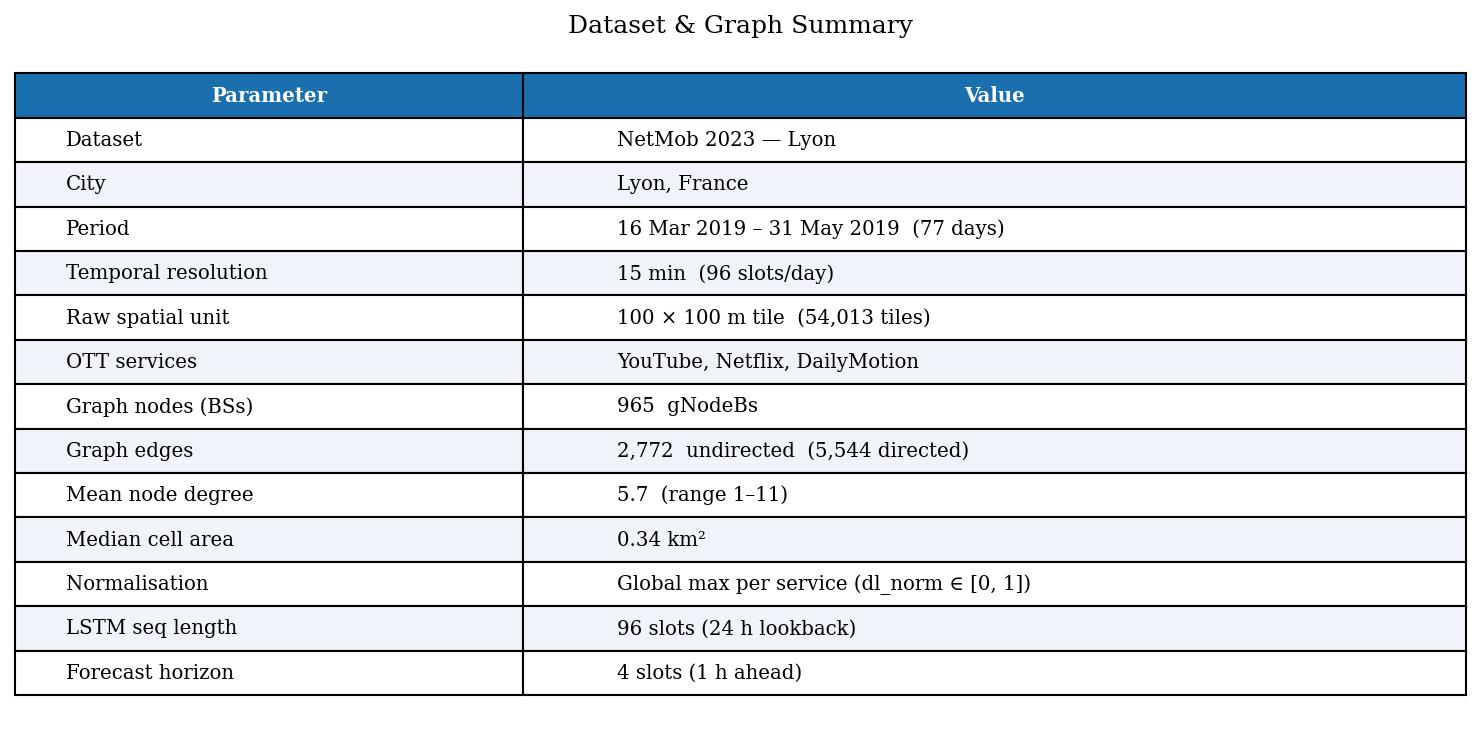

In [58]:
### Fig 14 — Dataset Summary Table
# Compact summary statistics table suitable for a thesis Methods section.

import matplotlib.table as tbl

rows = [
    ["Dataset",          "NetMob 2023 — Lyon"],
    ["City",             "Lyon, France"],
    ["Period",           "16 Mar 2019 – 31 May 2019  (77 days)"],
    ["Temporal resolution", "15 min  (96 slots/day)"],
    ["Raw spatial unit", "100 × 100 m tile  (54,013 tiles)"],
    ["OTT services",     "YouTube, Netflix, DailyMotion"],
    ["Graph nodes (BSs)", f"{len(bs_df):,}  gNodeBs"],
    ["Graph edges",      f"{len(graph_edges):,}  undirected  ({edge_index.shape[1]:,} directed)"],
    ["Mean node degree", f"{degree.mean():.1f}  (range {degree.min()}–{degree.max()})"],
    ["Median cell area", f"{(voronoi_map.groupby('site_id').size().median() * 0.01):.2f} km²"],
    ["Normalisation",    "Global max per service (dl_norm ∈ [0, 1])"],
    ["LSTM seq length",  "96 slots (24 h lookback)"],
    ["Forecast horizon", "4 slots (1 h ahead)"],
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=["Parameter", "Value"],
    cellLoc="left",
    loc="center",
    colWidths=[0.35, 0.65],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.55)

# Style header
for j in range(2):
    table[0, j].set_facecolor("#1a6faf")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternate row shading
for i in range(1, len(rows) + 1):
    fc = "#f0f4fa" if i % 2 == 0 else "white"
    for j in range(2):
        table[i, j].set_facecolor(fc)

ax.set_title("Dataset & Graph Summary", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig(FIGURES / "fig14_dataset_summary_table.pdf", bbox_inches="tight")
plt.show()